In [1]:
#!/usr/bin/env python
"""
compare_posteriors_dT_vs_speconly.py

Corner-plot comparison of two Cs 15272 MCMC posteriors:
  - blue : fit_spec + fit_dT  (dTTrue)
  - red  : fit_spec only      (dTFalse)

Shows 1σ (dashed) and 2σ (solid) contours with heavy smoothing.
Diagonal panels show smoothed 1D marginals.
"""
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
import emcee

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = os.path.expanduser('~/../../scratch/gpfs/MELCHIOR/cj1223/DIB')
FIG_DIR  = os.path.expanduser('~/DIB/figs')
os.makedirs(FIG_DIR, exist_ok=True)

_base = ('15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_'
         '{dt}_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_'
         'trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep.h5')

FILE_DT   = os.path.join(DATA_DIR, _base.format(dt='dTTrue'))
FILE_NODT = os.path.join(DATA_DIR, _base.format(dt='dTFalse'))

# ── Settings ──────────────────────────────────────────────────────────────────
BURNIN_TAU_MULT = 5       # burn-in = N × max(autocorr time)
SMOOTH_2D       = 3     # gaussian_filter sigma for 2D panels (heavy)
SMOOTH_1D       = 2     # smoothing for 1D marginal histograms
BINS_2D         = 60      # histogram bins for 2D panels
BINS_1D         = 80

COLOR_DT   = '#2166ac'    # blue  — spec + dT
COLOR_NODT = '#d6604d'    # red   — spec only

cmToMHz    = 29_979.2458
CENTRAL_WAV = 15272.27

labels = [
    r'$T_\mathrm{rot}$ [K]',
    r'$A$ [MHz]',
    r'$B$ [MHz]',
    r'$C$ [MHz]',
    r'$\alpha_A$ [%]',
    r'$\alpha_B$ [%]',
    r'$\alpha_C$ [%]',
    r'$\tau$ [Å]',
    r'$\delta_\mathrm{cen}$ [Å]',
]

# ── Unit conversion (matches notebook) ────────────────────────────────────────
def convert_units(s):
    s = s.copy()
    s[:, 1:4] *= cmToMHz                           # rot constants → MHz
    s[:, 4:7]  = (1.0 - s[:, 4:7]) * 100          # frac → % departure from ground state
    s[:, 7]    = CENTRAL_WAV**2 / 1e8 * s[:, 7]   # tau → Å units
    if s.shape[1] > 8:
        s[:, 8] = -CENTRAL_WAV**2 / 1e8 * s[:, 8] # center offset → Å
    return s

# ── Chain loading ──────────────────────────────────────────────────────────────
def load_flat(path, burnin_mult=BURNIN_TAU_MULT):
    reader  = emcee.backends.HDFBackend(path, read_only=True)
    chain   = reader.get_chain()       # (nsteps, nwalkers, ndim)
    logprob = reader.get_log_prob()    # (nsteps, nwalkers)
    tau     = emcee.autocorr.integrated_time(chain, tol=0)
    burnin  = int(burnin_mult * np.max(tau))
    burnin  = max(1, min(burnin, chain.shape[0] - 1))
    flat    = chain[burnin:].reshape(-1, chain.shape[2])
    lp      = logprob[burnin:].reshape(-1)
    mask    = np.isfinite(lp)
    name    = os.path.basename(path)
    print(f'{name[:70]}...')
    print(f'  nsteps={chain.shape[0]}, nwalkers={chain.shape[1]}, '
          f'ndim={chain.shape[2]}, burn-in={burnin}, '
          f'flat samples={mask.sum()}')
    return flat[mask]

print('Loading chains...')
flat_dt   = convert_units(load_flat(FILE_DT))
flat_nodt = convert_units(load_flat(FILE_NODT))

facs = np.array([1.0, 1.0, 1.0, 1.0,  1.0, 1.0, 1.0,  1.6, 1.0])
flat_dt/=facs
facs = np.array([1.0, 1.0, 1.0, 1.0,  1.0, 1/3.0, 1/3.0,  1.6, 1.0])
flat_nodt/=facs

ndim = flat_dt.shape[1]
assert flat_nodt.shape[1] == ndim, f'ndim mismatch: {flat_dt.shape[1]} vs {flat_nodt.shape[1]}'
print(f'\nndim={ndim}, labels={len(labels)}')

# Trim label list to actual ndim (in case center offset absent)
labels = labels[:ndim]

# ── Axis ranges: 0.5–99.5 percentile of union of both posteriors ───────────
ranges = []
for i in range(ndim):
    all_v = np.concatenate([flat_dt[:, i], flat_nodt[:, i]])
    lo, hi = np.percentile(all_v, [0.5, 99.5])
    margin = 0.08 * (hi - lo)
    ranges.append((lo - margin, hi + margin))

ranges = [(3, 25,), (0, 10000), (0, 7500), (0, 280), (0, 1), (0, 3.5), (0, 3.1), (0., 1.65), (-0.08, 0.06)]
# ── Contour drawing helpers ───────────────────────────────────────────────────
_SIGMA_FRACS = [0.393, 0.865]   # 2D enclosed fractions for 1σ / 2σ

def _levels(H):
    """Return density thresholds enclosing 1σ and 2σ probability mass."""
    Hf   = H.ravel()
    isrt = np.argsort(Hf)[::-1]
    cf   = np.cumsum(Hf[isrt]) / Hf.sum()
    return sorted([Hf[isrt[np.searchsorted(cf, f)]] for f in _SIGMA_FRACS])

def draw_contours_2d(ax, x, y, color, xrange, yrange):
    H, xe, ye = np.histogram2d(x, y, bins=BINS_2D,
                               range=[xrange, yrange])
    H  = gaussian_filter(H.astype(float), sigma=SMOOTH_2D)
    xc = 0.5 * (xe[:-1] + xe[1:])
    yc = 0.5 * (ye[:-1] + ye[1:])
    X, Y = np.meshgrid(xc, yc, indexing='ij')
    lvls = _levels(H)
    # inner contour (1σ) dashed, outer contour (2σ) solid
    for lvl, ls, al, lw in zip(lvls[::-1],
                                ['solid', 'dashed'],
                                [0.9, 0.9],
                                [1.8, 1.4]):
        ax.contour(X, Y, H, levels=[lvl], colors=[color],
                   linewidths=lw, linestyles=ls, alpha=al)

def draw_marginal_1d(ax, x, color, xrange):
    counts, edges = np.histogram(x, bins=BINS_1D, range=xrange, density=True)
    counts = gaussian_filter(counts.astype(float), sigma=SMOOTH_1D)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers, counts, color=color, lw=1.8)
    ax.fill_between(centers, counts, alpha=0.10, color=color)

Loading chains...
15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTT...
  nsteps=3771, nwalkers=64, ndim=9, burn-in=1664, flat samples=134848
15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTF...
  nsteps=7144, nwalkers=64, ndim=9, burn-in=4209, flat samples=187840

ndim=9, labels=9


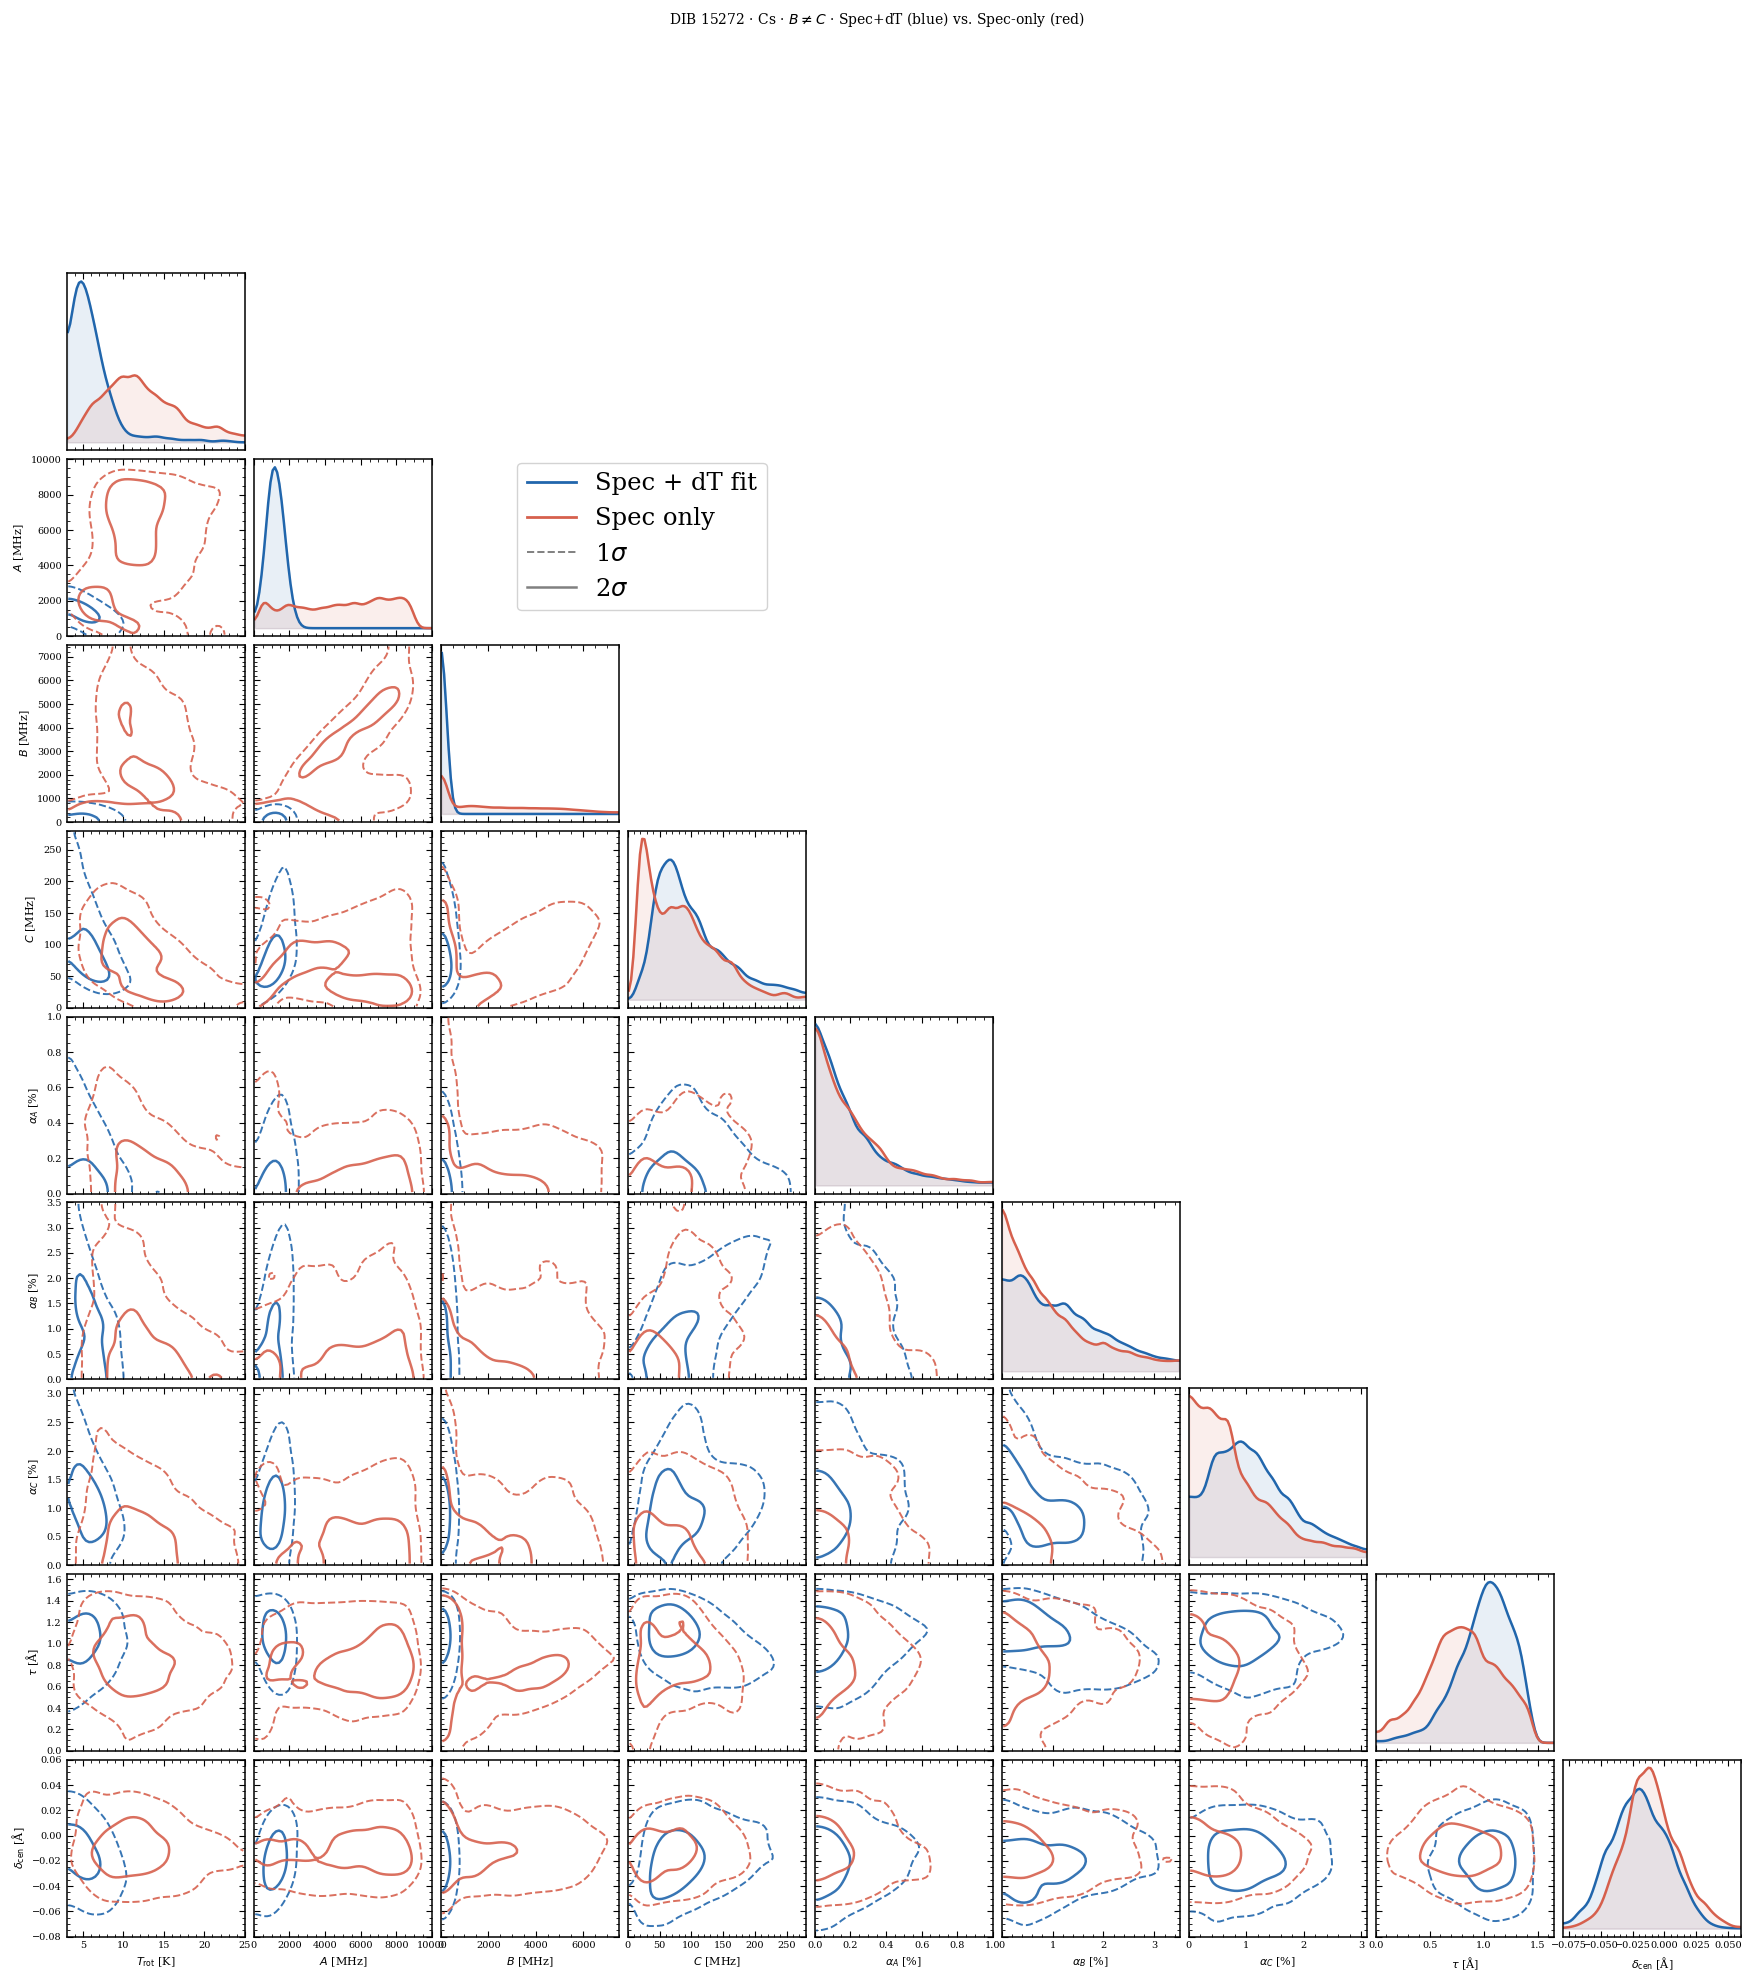

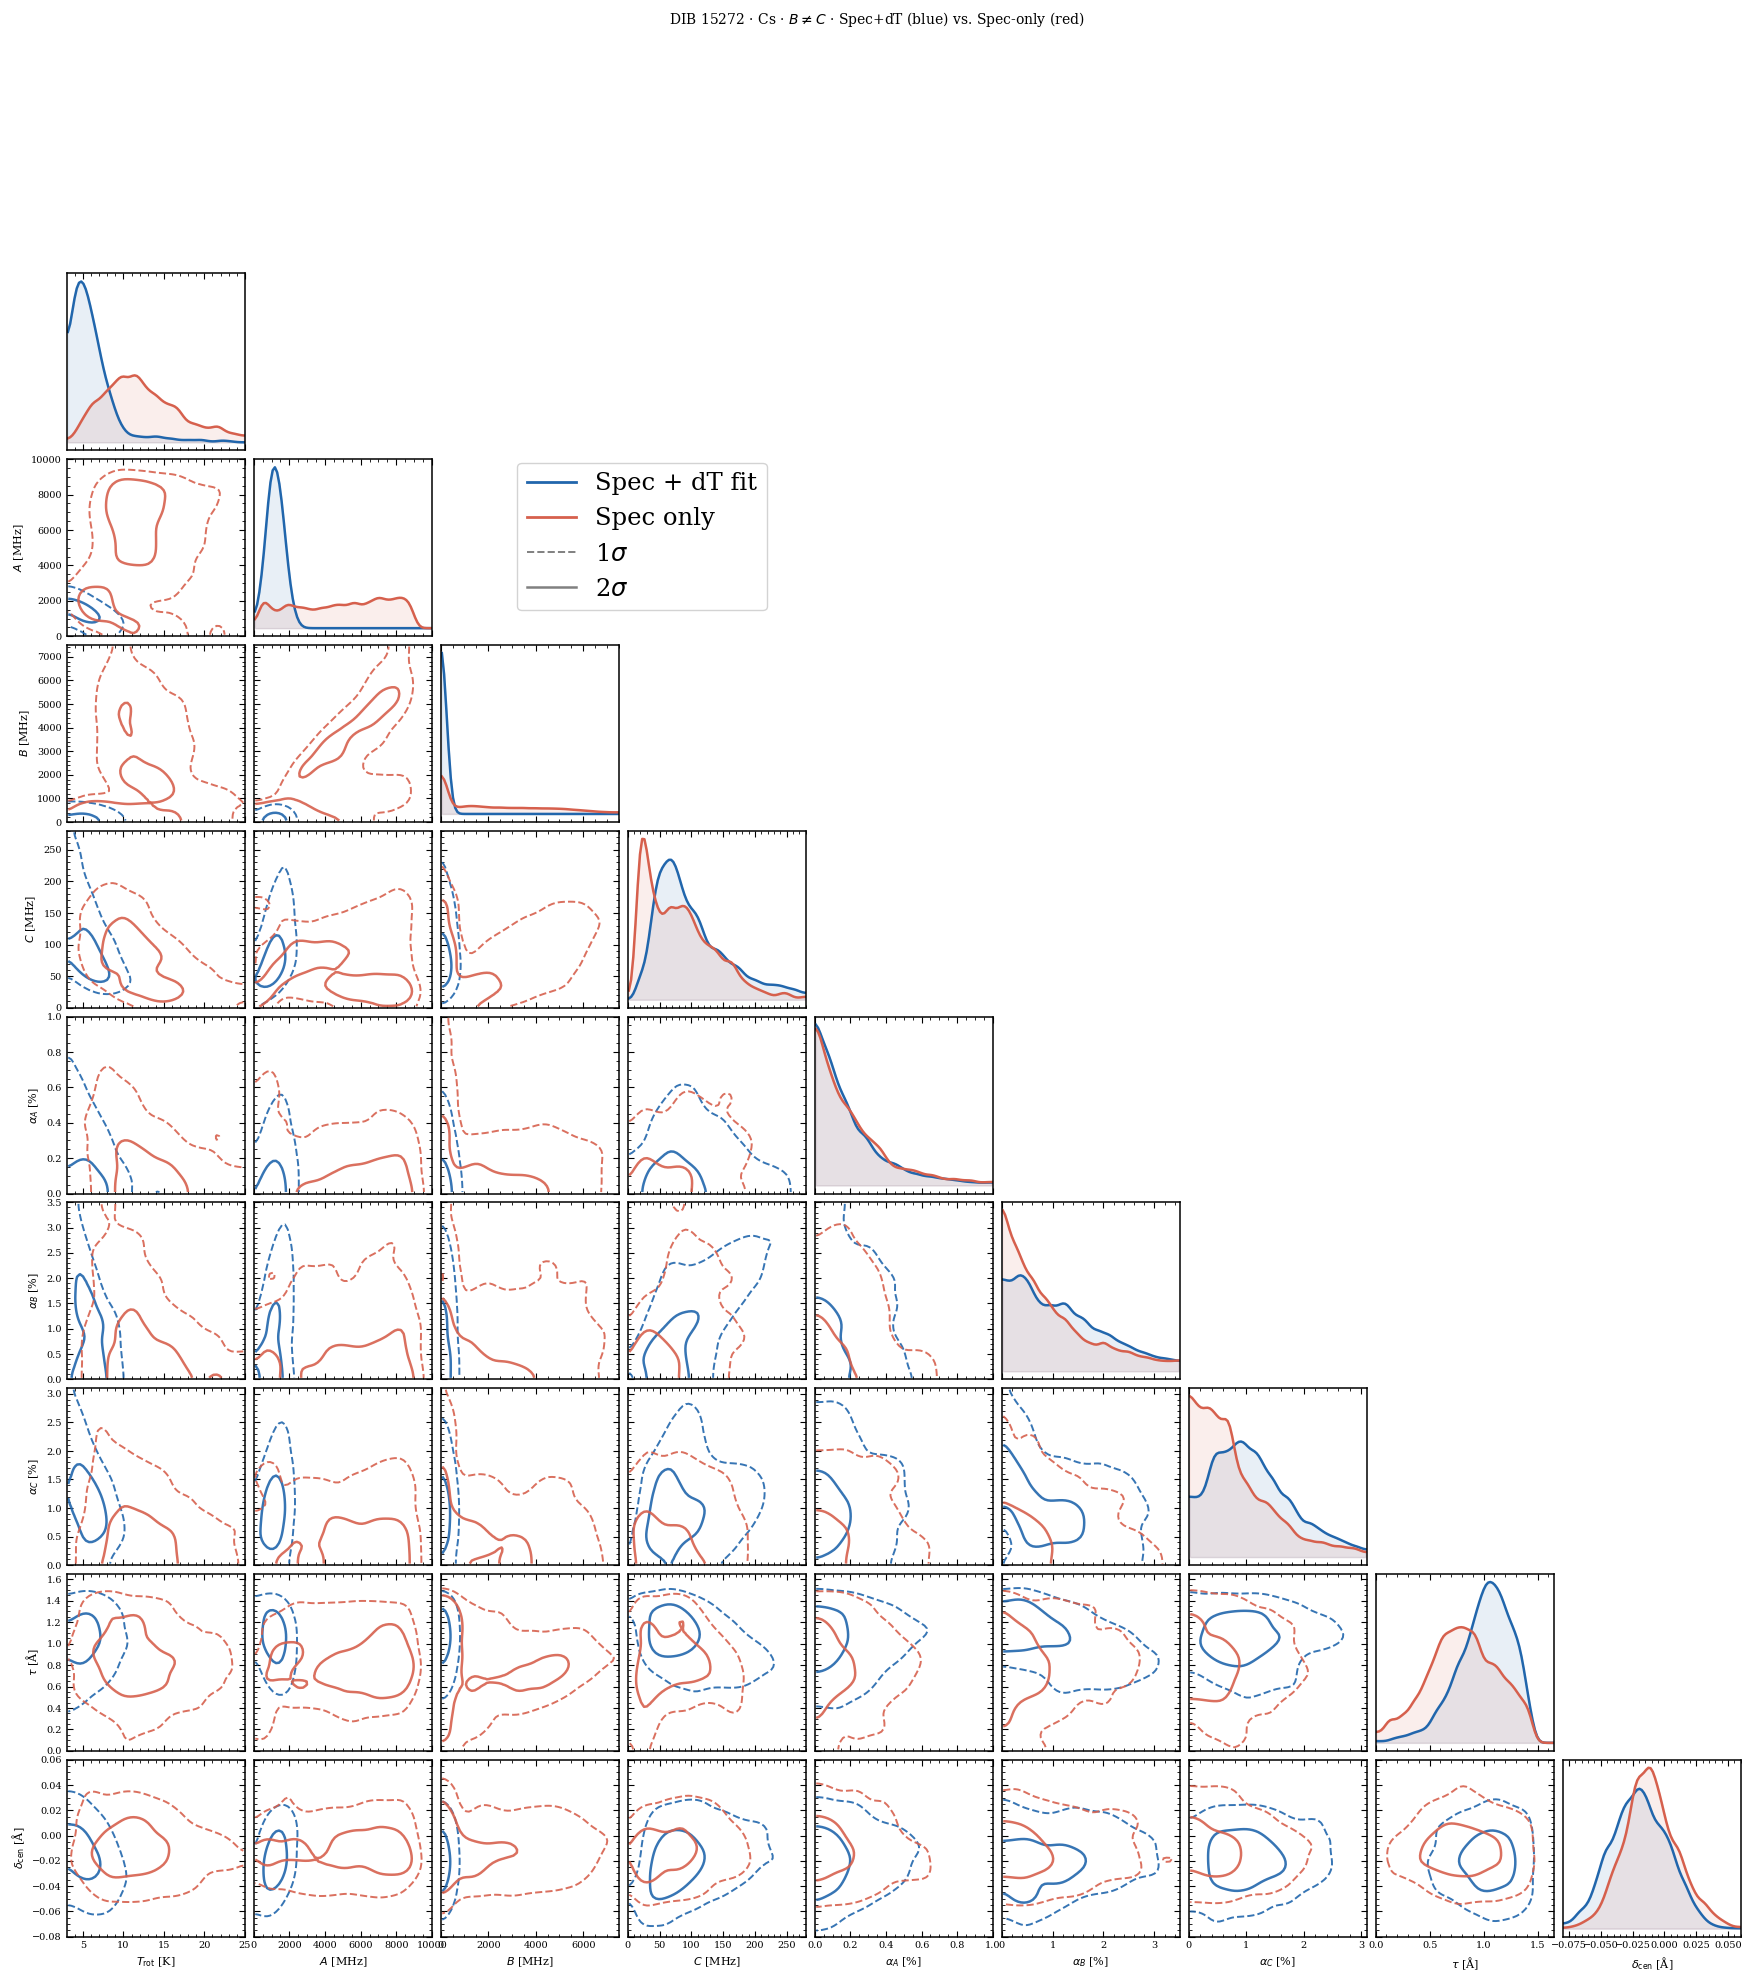

In [2]:

# ── Build figure ───────────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=8)
plt.rc('axes', linewidth=1.1)
plt.rc('xtick', labelsize=7, direction='in', top=True)
plt.rc('ytick', labelsize=7, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=4, pad=3)
plt.rc('xtick.minor', size=2)
plt.rc('ytick.major', size=4)
plt.rc('ytick.minor', size=2)

cell = 2.4   # inches per panel
fig, axes = plt.subplots(ndim, ndim,
                          figsize=(cell * ndim, cell * ndim))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for row in range(ndim):
    for col in range(ndim):
        ax = axes[row, col]

        if col > row:
            ax.set_visible(False)
            continue

        xr = ranges[col]
        yr = ranges[row]

        if col == row:
            draw_marginal_1d(ax, flat_dt[:, col],   COLOR_DT,   xr)
            draw_marginal_1d(ax, flat_nodt[:, col], COLOR_NODT, xr)
            ax.set_xlim(xr)
            ax.set_yticks([])
        else:
            draw_contours_2d(ax,
                             flat_dt[:, col],   flat_dt[:, row],
                             COLOR_DT,   xr, yr)
            draw_contours_2d(ax,
                             flat_nodt[:, col], flat_nodt[:, row],
                             COLOR_NODT, xr, yr)
            ax.set_xlim(xr)
            ax.set_ylim(yr)

        # Axis labels on outer edges only
        if row == ndim - 1:
            ax.set_xlabel(labels[col], fontsize=8, labelpad=4)
        else:
            ax.set_xticklabels([])

        if col == 0 and row > 0:
            ax.set_ylabel(labels[row], fontsize=8, labelpad=4)
        else:
            ax.set_yticklabels([])

# ── Legend ────────────────────────────────────────────────────────────────────
legend_lines = [
    Line2D([0], [0], color=COLOR_DT,   lw=2.0, label='Spec + dT fit'),
    Line2D([0], [0], color=COLOR_NODT, lw=2.0, label='Spec only'),
    Line2D([0], [0], color='gray', lw=1.4, ls='dashed', label=r'1$\sigma$'),
    Line2D([0], [0], color='gray', lw=1.8, ls='solid',  label=r'2$\sigma$'),
]
axes[0, 0].legend(handles=legend_lines, loc='upper right',
                  fontsize=17.5, framealpha=0.85, frameon=True, bbox_to_anchor = (4, 0))

fig.suptitle(
    r'DIB 15272 · Cs · $B\neq C$ · Spec+dT (blue) vs. Spec-only (red)',
    fontsize=10, y=1.002
)

# # ── Save ──────────────────────────────────────────────────────────────────────
# outpath = os.path.join(FIG_DIR, 'corner_compare_dT_vs_speconly_15272_Cs.png')
# fig.savefig(outpath, dpi=150, bbox_inches='tight')
# print(f'\nSaved → {outpath}')
# plt.show()

fig

In [4]:
# ── Controls for the enhanced comparison corner plot ─────────────────────────
FILL_CONTOURS   = True                # fill between 1σ and 2σ with low alpha
FILL_ALPHA      = 0.12               # base alpha; 1σ region gets 1.6×, 2σ annulus gets 0.7×
DIMS_TO_INCLUDE = list(range(ndim))  # indices of dimensions to plot, e.g. [0,1,2,3,7]
DIMS_TO_INCLUDE = [0,1,2,3]  # indices of dimensions to plot, e.g. [0,1,2,3,7]

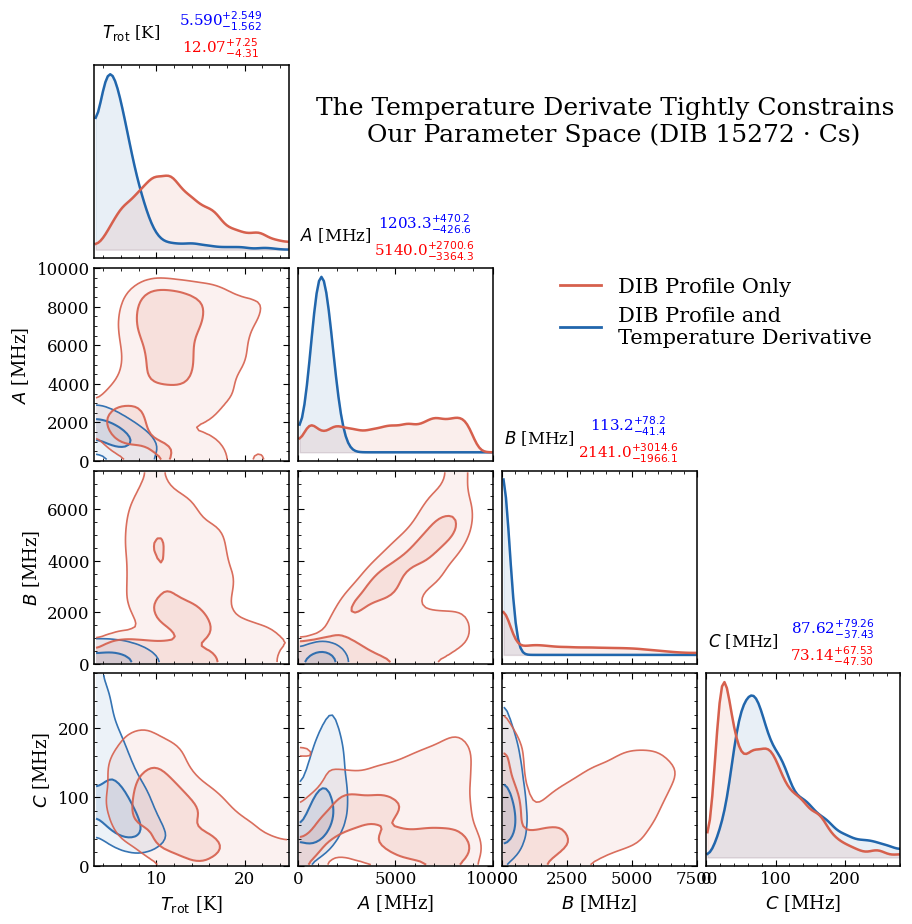

In [42]:
fs_title = 12

def make_comparison_corner(
        flat_a, flat_b,
        labels_all, ranges_all, dims,
        color_a, color_b, label_a, label_b,
        smooth_2d=3.5, smooth_1d=2.5,
        bins_2d=60, bins_1d=80,
        fill_contours=True, fill_alpha=0.12,
        cell_size=2.6, title='',
):
    # flat_a/flat_b : (N, ndim) flat samples (unit-converted)
    # labels_all    : list of all parameter label strings (len ndim)
    # ranges_all    : list of (lo, hi) tuples for all parameters
    # dims          : list of parameter indices to include in the plot
    # fill_contours : if True, fill 1σ and 2σ regions with low alpha
    # fill_alpha    : base opacity for the fill
    nd     = len(dims)
    sub_a  = flat_a[:, dims]
    sub_b  = flat_b[:, dims]
    sub_labels = [labels_all[i] for i in dims]
    sub_ranges = [ranges_all[i] for i in dims]

    _SIGMA_FRACS = [0.393, 0.865]   # 1σ / 2σ enclosed probability for 2D Gaussian

    def _levels(H):
        Hf   = H.ravel()
        isrt = np.argsort(Hf)[::-1]
        cf   = np.cumsum(Hf[isrt]) / Hf.sum()
        # lvls[0] = 2σ threshold (lower density), lvls[1] = 1σ threshold (higher density)
        return sorted([Hf[isrt[np.searchsorted(cf, f)]] for f in _SIGMA_FRACS])

    def draw_2d(ax, x, y, color, xr, yr):
        H, xe, ye = np.histogram2d(x, y, bins=bins_2d, range=[xr, yr])
        H  = gaussian_filter(H.astype(float), sigma=smooth_2d)
        xc = 0.5 * (xe[:-1] + xe[1:])
        yc = 0.5 * (ye[:-1] + ye[1:])
        X, Y = np.meshgrid(xc, yc, indexing='ij')
        lvls = _levels(H)           # [lv_2sig, lv_1sig]
        if fill_contours:
            # 1σ interior (most opaque)
            ax.contourf(X, Y, H, levels=[lvls[1], H.max() + 1e-30],
                        colors=[color], alpha=fill_alpha * 1.6)
            # annular 1σ–2σ region (lighter)
            ax.contourf(X, Y, H, levels=[lvls[0], lvls[1]],
                        colors=[color], alpha=fill_alpha * 0.7)
        # 1σ: solid inner line; 2σ: dashed outer line
        for lvl, ls, lw in zip(lvls[::-1], ['solid', 'solid'], [1.5, 1.2]):
            ax.contour(X, Y, H, levels=[lvl], colors=[color],
                       linewidths=lw, linestyles=ls, alpha=0.9)

    def draw_1d(ax, x, color, xr):
        counts, edges = np.histogram(x, bins=bins_1d, range=xr, density=True)
        counts = gaussian_filter(counts.astype(float), sigma=smooth_1d)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, counts, color=color, lw=1.8)
        ax.fill_between(centers, counts, alpha=0.10, color=color)

    def fmt_stats(vals):
        med = np.median(vals)
        lo  = med - np.percentile(vals, 16)
        hi  = np.percentile(vals, 84) - med
        mag = max(abs(med), hi, lo, 1e-10)
        if   mag > 100: f = '.1f'
        elif mag > 10:  f = '.2f'
        elif mag > 1:   f = '.3f'
        else:           f = '.4f'
        return f'{med:{f}}$^{{+{hi:{f}}}}_{{-{lo:{f}}}}$'

    mpl.rcParams.update(mpl.rcParamsDefault)
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rc('font', family='serif', size=13)
    plt.rc('axes', linewidth=1.1)
    plt.rc('xtick', labelsize=12, direction='in', top=True)
    plt.rc('ytick', labelsize=12, direction='in', right=True)
    plt.rc('xtick.minor', visible=True)
    plt.rc('ytick.minor', visible=True)
    plt.rc('xtick.major', size=4, pad=3)
    plt.rc('xtick.minor', size=2)
    plt.rc('ytick.major', size=4)
    plt.rc('ytick.minor', size=2)

    fig, axes = plt.subplots(nd, nd, figsize=(cell_size * nd, cell_size * nd))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    if nd == 1:
        axes = np.array([[axes]])
    elif nd > 1 and np.asarray(axes).ndim == 1:
        axes = np.asarray(axes)[np.newaxis, :]

    for row in range(nd):
        for col in range(nd):
            ax = axes[row, col]
            if col > row:
                ax.set_visible(False)
                continue
            xr = sub_ranges[col]
            yr = sub_ranges[row]

            if col == row:
                draw_1d(ax, sub_a[:, col], color_a, xr)
                draw_1d(ax, sub_b[:, col], color_b, xr)
                ax.set_xlim(xr)
                ax.set_yticks([])
                # Stacked titles: parameter name, then blue stats, then red stats
                lbl   = sub_labels[col]
                txt_a = fmt_stats(sub_a[:, col])
                txt_b = fmt_stats(sub_b[:, col])
                ax.annotate(lbl,   xy=(.19, 1.12), xycoords='axes fraction',
                            ha='center', va='bottom', fontsize=fs_title,
                            clip_on=False, annotation_clip=False)
                ax.annotate(txt_a, xy=(0.65, 1.17), xycoords='axes fraction',
                            ha='center', va='bottom', fontsize=fs_title/1.1,
                            color='blue', clip_on=False, annotation_clip=False)
                ax.annotate(txt_b, xy=(0.65, 1.03), xycoords='axes fraction',
                            ha='center', va='bottom', fontsize=fs_title/1.1,
                            color='red', clip_on=False, annotation_clip=False)
            else:
                draw_2d(ax, sub_a[:, col], sub_a[:, row], color_a, xr, yr)
                draw_2d(ax, sub_b[:, col], sub_b[:, row], color_b, xr, yr)
                ax.set_xlim(xr)
                ax.set_ylim(yr)

            if row == nd - 1:
                ax.set_xlabel(sub_labels[col], fontsize=13, labelpad=4)
            else:
                ax.set_xticklabels([])
            if col == 0 and row > 0:
                ax.set_ylabel(sub_labels[row], fontsize=13, labelpad=4)
            else:
                ax.set_yticklabels([])

    legend_lines = [
        Line2D([0], [0], color=color_b, lw=2.0, label = 'DIB Profile Only'),
        Line2D([0], [0], color=color_a, lw=2.0, label = 'DIB Profile and \nTemperature Derivative'),
#         Line2D([0], [0], color='gray',  lw=1.8, ls='solid',  label=r'1$\sigma$'),
#         Line2D([0], [0], color='gray',  lw=1.4, ls='dashed', label=r'2$\sigma$'),
    ]
    axes[0, 0].legend(handles=legend_lines, loc='upper right',
                      fontsize = 15, framealpha = 0.85, frameon = False, bbox_to_anchor = (4.1, 0.0))
    if title:
        fig.suptitle(title, fontsize=18, y=0.85, x = 0.62)
    return fig


fig2 = make_comparison_corner(
    flat_dt, flat_nodt,
    labels, ranges,
    dims          = DIMS_TO_INCLUDE,
    color_a       = COLOR_DT,
    color_b       = COLOR_NODT,
    label_a       = 'Spec + dT',
    label_b       = 'Spec only',
    fill_contours = FILL_CONTOURS,
    fill_alpha    = FILL_ALPHA,
    title         = 'The Temperature Derivate Tightly Constrains \n Our Parameter Space (DIB 15272 · Cs)',
)
fig2